In [1]:
import pandas as pd
import numpy as np

In [2]:
dataset_path='PJME_hourly.csv'

In [3]:
df=pd.read_csv(dataset_path,parse_dates=['Datetime'],index_col='Datetime')
df = df.sort_index()
df = df[~df.index.duplicated(keep='first')]

In [4]:
def create_time_features(df):
    df = df.copy()
    df['hour']=df.index.hour
    df['dayofweek']=df.index.dayofweek
    df['quarter']=df.index.quarter
    df['month']=df.index.month
    df['year']=df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
    return df

In [5]:
df = create_time_features(df)

In [6]:
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,is_weekend
Datetime,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,0
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,0
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,0
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,0
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,0
...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,0
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,0
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,0


In [7]:
#3 Chronological Split (Cutoff at Jan 1, 2015)
split_date='2015-01-01'

In [8]:
train = df.loc[df.index<split_date].copy()
test = df.loc[df.index>=split_date].copy()

In [9]:
print(f"Training set rows: {len(train)} (Dates: {train.index.min()} to {train.index.max()})")
print(f"Testing set rows: {len(test)} (Dates: {test.index.min()} to {test.index.max()})")

Training set rows: 113925 (Dates: 2002-01-01 01:00:00 to 2014-12-31 23:00:00)
Testing set rows: 31437 (Dates: 2015-01-01 00:00:00 to 2018-08-03 00:00:00)


In [10]:
def create_lag_features(df):
    df = df.copy()

    # Map target value back in time
    df['lag_1_hour']=df['PJME_MW'].shift(1)
    df['lag_24_hours']=df['PJME_MW'].shift(24)
    df['lag_7_days']=df['PJME_MW'].shift(7*24)
    return df
df=create_lag_features(df)

print("--- Early Rows with NaNs due to shifting ---")
print(df[['PJME_MW', 'lag_1_hour', 'lag_24_hours', 'lag_7_days']].head(5))

print("\n--- Rows after 168 hours (7 days) where lag values fill up ---")
print(df[['PJME_MW', 'lag_1_hour', 'lag_24_hours', 'lag_7_days']].iloc[170:175])


--- Early Rows with NaNs due to shifting ---
                     PJME_MW  lag_1_hour  lag_24_hours  lag_7_days
Datetime                                                          
2002-01-01 01:00:00  30393.0         NaN           NaN         NaN
2002-01-01 02:00:00  29265.0     30393.0           NaN         NaN
2002-01-01 03:00:00  28357.0     29265.0           NaN         NaN
2002-01-01 04:00:00  27899.0     28357.0           NaN         NaN
2002-01-01 05:00:00  28057.0     27899.0           NaN         NaN

--- Rows after 168 hours (7 days) where lag values fill up ---
                     PJME_MW  lag_1_hour  lag_24_hours  lag_7_days
Datetime                                                          
2002-01-08 03:00:00  28375.0     28670.0       25641.0     28357.0
2002-01-08 04:00:00  28542.0     28375.0       25666.0     27899.0
2002-01-08 05:00:00  29261.0     28542.0       26328.0     28057.0
2002-01-08 06:00:00  31348.0     29261.0       28267.0     28654.0
2002-01-08 07:00:00 

In [11]:
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,is_weekend,lag_1_hour,lag_24_hours,lag_7_days
Datetime,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,0,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,0,30393.0,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,0,29265.0,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,0,28357.0,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,0,27899.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,0,45641.0,46912.0,46337.0
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,0,44057.0,45985.0,44542.0
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,0,43256.0,44094.0,42638.0


In [12]:
def create_rolling_features(df):
    df=df.copy()
    df['rolling_mean_24h']= df['PJME_MW'].shift(1).rolling(window=24).mean()
    df['rolling_mean_7d']= df['PJME_MW'].shift(1).rolling(window=24*7).mean()
    return df
df = create_rolling_features(df)
df_clean=df.dropna()
print("--- Final Cleaned Dataset Info ---")
df_clean.info()
print(f"Dropped {len(df)-len(df_clean)} rows containing NaN values")



--- Final Cleaned Dataset Info ---
<class 'pandas.DataFrame'>
DatetimeIndex: 145194 entries, 2002-01-08 01:00:00 to 2018-08-03 00:00:00
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   PJME_MW           145194 non-null  float64
 1   hour              145194 non-null  int32  
 2   dayofweek         145194 non-null  int32  
 3   quarter           145194 non-null  int32  
 4   month             145194 non-null  int32  
 5   year              145194 non-null  int32  
 6   dayofyear         145194 non-null  int32  
 7   is_weekend        145194 non-null  int64  
 8   lag_1_hour        145194 non-null  float64
 9   lag_24_hours      145194 non-null  float64
 10  lag_7_days        145194 non-null  float64
 11  rolling_mean_24h  145194 non-null  float64
 12  rolling_mean_7d   145194 non-null  float64
dtypes: float64(6), int32(6), int64(1)
memory usage: 12.2 MB
Dropped 168 rows containing NaN values


In [13]:
df_clean

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,is_weekend,lag_1_hour,lag_24_hours,lag_7_days,rolling_mean_24h,rolling_mean_7d
Datetime,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,1,1,1,2002,8,0,31187.0,26862.0,30393.0,33452.583333,32519.511905
2002-01-08 02:00:00,28670.0,2,1,1,1,2002,8,0,29445.0,25976.0,29265.0,33560.208333,32513.869048
2002-01-08 03:00:00,28375.0,3,1,1,1,2002,8,0,28670.0,25641.0,28357.0,33672.458333,32510.327381
2002-01-08 04:00:00,28542.0,4,1,1,1,2002,8,0,28375.0,25666.0,27899.0,33786.375000,32510.434524
2002-01-08 05:00:00,29261.0,5,1,1,1,2002,8,0,28542.0,26328.0,28057.0,33906.208333,32514.261905
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,0,45641.0,46912.0,46337.0,40021.875000,35913.809524
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,0,44057.0,45985.0,44542.0,39902.916667,35900.238095
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,0,43256.0,44094.0,42638.0,39789.208333,35892.583333


In [26]:
file_path = "c:/Akhil/AI_Engineer/1stProject/cleaned_dataset.csv"

df_clean.to_csv(file_path, index=True)


In [14]:
# Define feature columns vs target column
FEATURES=['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'is_weekend', 'lag_1_hour', 'lag_24_hours', 'lag_7_days', 'rolling_mean_24h', 'rolling_mean_7d']

In [15]:
TARGET='PJME_MW'

In [16]:
split_date='2015-01-01'

In [17]:
x_train = df_clean.loc[df_clean.index < split_date, FEATURES]
y_train = df_clean.loc[df_clean.index < split_date, TARGET]

In [18]:
print(f"x_train shape {x_train.shape}, y_train shape: {y_train.shape}")

x_train shape (113757, 12), y_train shape: (113757,)


In [19]:
x_test=df_clean.loc[df_clean.index>=split_date, FEATURES]
y_test=df_clean.loc[df_clean.index>=split_date, TARGET]
print(f"x_train shape {x_test.shape}, y_train shape: {y_test.shape}")

x_train shape (31437, 12), y_train shape: (31437,)


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#Design a Central Evaluation function for the required metrics
def evaluate_predictions(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape= np.mean(np.abs((y_true-y_pred)/y_true)) *100
    r2 = r2_score(y_true, y_pred)

    metrics_summary = {
        'Model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2),
        'R2': round(r2, 2)
    }
    return metrics_summary

# Naive Baseline: Use 'lag_24_hours' as our prediction
baseline_preds = x_test['lag_24_hours']

# Score the baseline
baseline_results = evaluate_predictions(y_test, baseline_preds, 'Naive Baseline')

results_df = pd.DataFrame([baseline_results])
results_df



,Model,MAE,RMSE,MAPE,R2
0,Naive Baseline,2209.02,3025.1,6.96,0.78


In [21]:
# Linear Regression
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression Model
lr_model=LinearRegression()

# Train the Model using our Training Data Matrix
lr_model.fit(x_train,y_train)

# Generate predictions on the testing data matrix
lr_preds = lr_model.predict(x_test)

# Evaluate the Model based on the predictions
lr_results= evaluate_predictions(y_test, lr_preds, 'Linear Regression')

results_df = pd.concat([results_df, pd.DataFrame([lr_results])], ignore_index=True)
results_df

,Model,MAE,RMSE,MAPE,R2
0,Naive Baseline,2209.02,3025.10,6.96,0.78
1,Linear Regression,968.17,1237.19,3.10,0.96


In [22]:
# Random Forest Regressor Model
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest with Optimized parameters for local speed
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Training Random Forest Regression Model
print(f"Training Random Forest Classifier Models this may take some time......")
rf_model.fit(x_train,y_train)

## Generate predictions on the testing data 
rf_preds= rf_model.predict(x_test)

#Evaluate the Model
rf_results = evaluate_predictions(y_test,rf_preds,'Random Forest Regressor')
results_df = pd.concat([results_df,pd.DataFrame([rf_results])], ignore_index=True)
results_df

Training Random Forest Classifier Models this may take some time......


,Model,MAE,RMSE,MAPE,R2
0,Naive Baseline,2209.02,3025.10,6.96,0.78
1,Linear Regression,968.17,1237.19,3.10,0.96
2,Random Forest Regressor,467.70,636.33,1.47,0.99


In [23]:
import xgboost as xgb

xgb_model=xgb.XGBRegressor(
    n_estimator=1000,
    early_stopping_rounds=50,
    learning_rate=0.01,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
# Training the model
xgb_model.fit(
    x_train, y_train,
    eval_set=[(x_train,y_train),(x_test,y_test)],
    verbose=100
)
# Model Prediction
xgb_preds = xgb_model.predict(x_test)
# Evaluate Predictions
xgb_results = evaluate_predictions(y_test, xgb_preds, 'XGBoost')
results_df = pd.concat([results_df, pd.DataFrame([xgb_results])], ignore_index=True)
print("\n---- Final Model Comparison Table")
results_df

[0]	validation_0-rmse:6393.38757	validation_1-rmse:6459.23266


c:\Users\akhil\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\callback.py:385: UserWarning: [15:42:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  self.starting_round = model.num_boosted_rounds()


[99]	validation_0-rmse:2562.54932	validation_1-rmse:2619.33880

---- Final Model Comparison Table


,Model,MAE,RMSE,MAPE,R2
0,Naive Baseline,2209.02,3025.10,6.96,0.78
1,Linear Regression,968.17,1237.19,3.10,0.96
2,Random Forest Regressor,467.70,636.33,1.47,0.99
3,XGBoost,2134.93,2619.34,7.16,0.84


C:\Users\akhil\AppData\Local\Temp\ipykernel_5188\4175583519.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, ax=axes[1], palette='viridis')


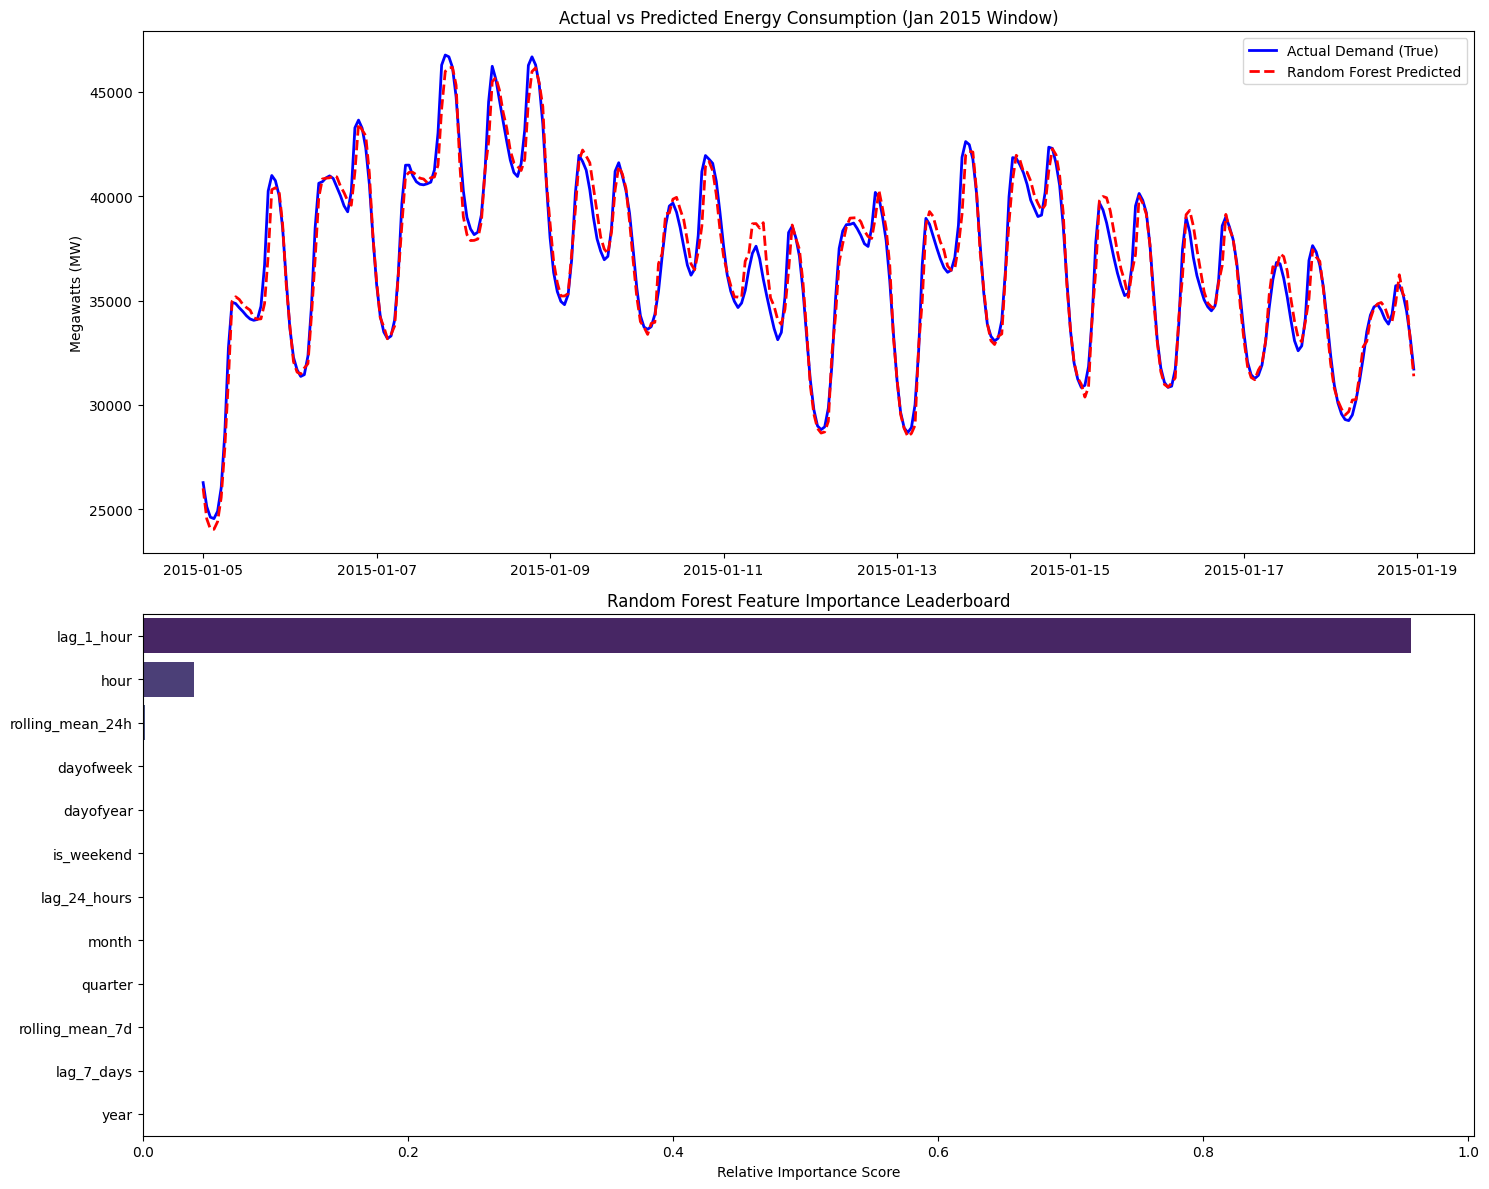

In [58]:
from seaborn._core.properties import LineWidth
import seaborn as sns
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(2,1,figsize=(15,12))


test_window = y_test.loc['2015-01-05':'2015-01-18']
rf_window_preds = pd.Series(rf_preds, index=y_test.index).loc['2015-01-05':'2015-01-18']

# Plot Actual vs Predicted
axes[0].plot(test_window.index, test_window.values, label='Actual Demand (True)', color='blue', linewidth=2)
axes[0].plot(test_window.index, rf_window_preds.values, label='Random Forest Predicted', color='red', linestyle='--', linewidth=2)
axes[0].set_title('Actual vs Predicted Energy Consumption (Jan 2015 Window)')
axes[0].set_ylabel('Megawatts (MW)')
axes[0].legend()

# Sort Random Forest Feature Importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [FEATURES[i] for i in indices]
sorted_importances = importances[indices]

# Plot Feature Importances
sns.barplot(x=sorted_importances, y=sorted_features, ax=axes[1], palette='viridis')
axes[1].set_title('Random Forest Feature Importance Leaderboard')
axes[1].set_xlabel('Relative Importance Score')

plt.tight_layout()
plt.show()


In [24]:
import joblib
import json
import os
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)
joblib.dump(rf_model, "models/best_model.pkl")

best_metrics= results_df.iloc[2].to_dict()

with open('reports/metrics.json', 'w') as f:
    json.dump(best_metrics, f, indent=4)

print("Successfully exported 'best_model.pkl' and 'metrics.json'!")

Successfully exported 'best_model.pkl' and 'metrics.json'!
